# Lab 7.05 - Time series analysis

In [1]:
# Package Imports
import numpy as np                                  # Scientific computing
import pandas as pd                                 # Dataframe manipulation
import scipy.stats as stats                         # Statistical tests
import matplotlib.pyplot as plt                     # Basic visualization
import seaborn as sns                               # Advanced data visualization
from sklearn.linear_model import LinearRegression   # Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

### Exercise 5 - Alcoholic beverages sales

The file US Retail.csv contains monthly retail sales of beer, wine, and liquor at U.S. liquor stores.

- Is seasonality present in these data?
- Create a time series chart of the data. Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?
- Split the dataset in a train (1992-01-01 up to and including 2008-12-01) and test set (2009-01-01 up to and including 2009-12-01)  
- Create and train the model. 
- Predict the values for 2009.
- Create a plot with the train data, the fitted values, the test data and the predicted values.
- Calculate MAE

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/US%20Retail.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

,Total Sales
Month,
1992-01-01,1519
1992-02-01,1551
1992-03-01,1606
1992-04-01,1686
1992-05-01,1834


<Axes: title={'center': 'Observed Time Series'}, xlabel='Month'>

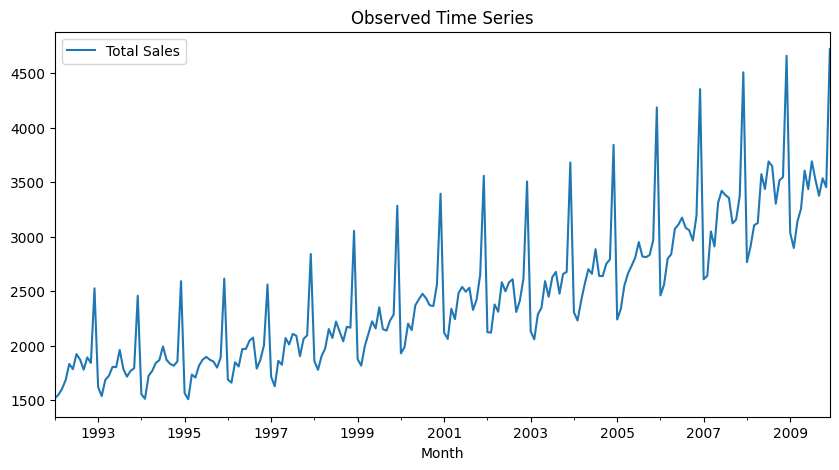

In [6]:
data.plot(y='Total Sales', figsize=[10,5], title='Observed Time Series')

> Here we can see that there is definitely seasonality (every end of year there is a spike)

Based on what you see, which of the exponential smoothing models do you think should be used for forecasting? Why?

In [7]:
train = data[:'2008-12-01']
test = data['2009-01-01':]
print(train.tail())
print(test.head())

            Total Sales
Month                  
2008-08-01         3647
2008-09-01         3303
2008-10-01         3516
2008-11-01         3548
2008-12-01         4660
            Total Sales
Month                  
2009-01-01         3036
2009-02-01         2897
2009-03-01         3140
2009-04-01         3256
2009-05-01         3606


In [13]:
# Because there is a seasonal component -> triple exponential smoothing model
data_tes = ExponentialSmoothing(train['Total Sales'], trend='add', seasonal='mul', seasonal_periods=12, freq='MS').fit()
data_tes_forecast = data_tes.forecast(12)
data['TES'] = data_tes.fittedvalues

In [14]:
data.head()

,Total Sales,TES
Month,,
1992-01-01,1519,1520.928507
1992-02-01,1551,1514.778855
1992-03-01,1606,1683.395493
1992-04-01,1686,1666.113313
1992-05-01,1834,1822.953764


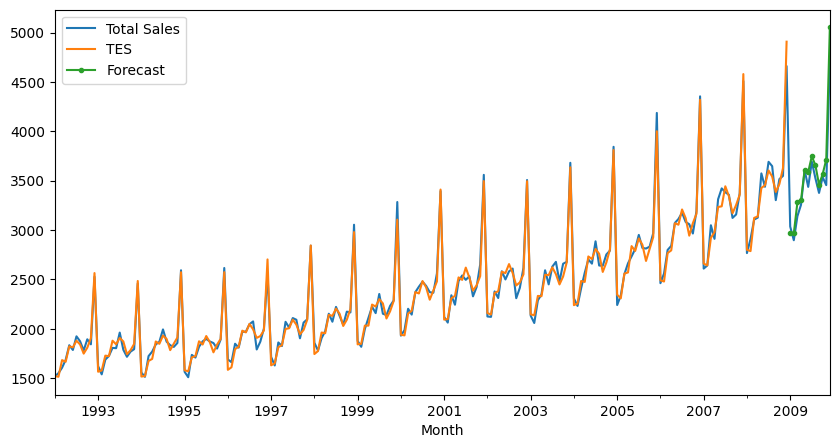

In [15]:
data.plot(y=['Total Sales', 'TES'], figsize=[10,5])
data_tes_forecast.plot(marker='.', legend=True, label='Forecast');

## Source
Business Analytics Data Analysis & Decision Making 